CONDITIONAL GANS (cGAN): GUIDARE LA GENERAZIONE CON ETICHETTE.

Una GAN sa generare qualcosa di realistico, ma come faccio a dirle che cosa voglio generare?
Aggiungo una condizione sia nel Genereatore sia al Discriminatore

La variabile di condizionamento, y, viene fornita sia a G sia a D. 
Nel caso di MINST l'etichetta è la cifra rappresentata.

Una GAN:
rumore z -> Generator -> immagine casuale
ma non controlli l'immagine generata
Una cGAN invece:
rumore z + label y = 7 -> Generator -> immagine di un 7

Da GAN a cGAN
Nella GAN standard abbiamo G(z) dove z è il vettore dello spazio latente.
Il Generetor vede solo esempio 100 numeri casuali e deve imparare 'immagine plausibile' ma non gli dici cosa deve rappresentare.

Con la Conditional GAN g(z,y) z=rumore casuale y=condizione
Il rumore mantiene la varietà, la condizione fornisce il controllo. 
Anche il rumore è fondamentale perchè se chiedo alla rete "generami un 7" non voglio sempre lo stesso 7, qundi:
y - determina la categoria
z - determina le variazioni
in altri termini:
label - contenuto
noise - stile/variazione

Nel cGAN si cerca di imparare la distribuzione delle immagini x, dato la condizione y.
La cGAN impara quindi diverse distribuzioni condizionate.
G genera spendando che l'immagine generata piaccia al Condizionatore.

Ma la CONDIZIONE non è necessariamente una classe, può essere:
etichetta, testo, immagine, attributo, numero, categoria, informazione strutturata.
Conditional significa che la generazione dipende da un'informazione aggiuntiva.

La cGAN fornisce y (l'etichetta) sia al Generator sia al Discriminator.
D (Discriminator) deve conoscere y (l'etichetta), deve guidare due cose contemporaneamente:
1. L'immagine è reale?
2. L'immagine è coerente con la condizione richiesta?

D non chiede più soltanto real o fake, ma anche se è compatibile con l'etichetta y
Questo permette a D di insegnare a G a rispettare la condizione.

Nelle GAN classiche non abbiamo il controllo su cosa il modello generi: campioniamo dal rumore e accettiamo il risultato. Le cGAN risolvono questo limite, introducendo una variabile condizionale y.
Iniettando l'informazione della classe (y) sia nel Generatore che nel Discriminatore, trasformiamo il gioco da una modellazione di densità semplice a una modellazione di probabilità condizionata.

Pensa alla variabile y come a un etichetta o a un comando.
esempio: disegna un 7

Come rappresentiamo una label?

Al Generatore non do più solo un vettore casuale (z), ma la concatenazione di z e y
Il Discriminatore riceve l'immagine (reale o fake) insieme alla rispettiva etichetta y per valutarne la coerenza. Questa immagine è reale, dato che dovrebbe essere un 7 (y)?
L'etichetta agisce come una guida che vincola il mapping verso una specifica regione della varietà dei dati.
E' come se aggiungessimo il timone in una barca a vela
La funzione obbiettivo si evolve per riflettere la natura condizionale della sfida tra le due reti neurali.

Come inietiamo queste informazoni

Una possibilità è ONE-HOT ENCODING
esempio
0 -> [1,0,0,0,0,0,0,0,0,0]
1 -> [0,1,0,0,0,0,0,0,0,0]
7 -> [0,0,0,0,0,0,0,1,0,0]
Quindi la classe 7 diventa un vettore di 10 valori tutti 0 ed un solo 1
A G passi sia z che y, cioè passi la casualità e la condizione
La concatenazione può avvenire a diversi livelli della rete, non solo nel primo layer, per rafforzare il vincolo condizionale.

Quando le classi aumentao il hon-hot non basta più

EMBEDDING invece di one-hot
Nelle implementazioni più interessanti non si una necessariamente il one-hot, puoi usare nn.Embedding()
One-hot label rappresentata rigidamente
Embedding: rappresentazione densa ed apprendibile della label imparata dalla rete.
La cGAN impare che il concetto di cane è vicino a quello di lupo, condividono caratteristiche strutturali simili nello spazio latente.
Questo permette al modello di condividere la conoscenza strutturale tra classi simili. Rendendo la generazione molto più efficiente.

Queste informazioni aggiuntive ci portano al vantaggio più imprtante delle cGAN

Controllo dell'Output
In vantaggio principale delle cGAN è la capacità di interrogare il modello in modo deterministico rispetto alla categoria desiderata.
Mentra una GAN standard produce un numero a caso da MNIST, una cGAN può essere istruita per generare esasttamente una sequenza specifica di cifre.

Se stai costruendo un sistema di riconoscimenti cifre, e mancano degli esempi del numero 8, non può aspettare che una GAN standard ne generi uno per caso, con una cGAN puoi genersare 1000 varianti dell'8 in pochi secondi.

Ma cosa succede se manteniamo lo stesso rumore e cambiamo solo l'ordine?

Fornendo la stessa coordinata z di rumore (che rappresnta lo stile, lo spessore del tratto, o l'angolazione), e cambiando solo la y (label), possiamo osservare come lo stile rimanga costante mentre cambia l'oggetto. E' la prova che la rete ha separato il come (lo stile) da il cosa (il contenuto).
Il condizionamento riduce l'ambiguità del processo generativo, rendendo l'addestramento spesso più stabile. poicè il modello ha un obbiettivo specifico, tende ad essere più stabile rispetto alle semplici GAN
Le cGAN permettono di esplorare distribuzioni multi-modali in modo granulare e controllato
Il modello impara la distribuzione di probabilità condizonata invece della marginale singola probabilità

Nella GAN classiche il modello potrebbe fossilizzarsi solo nel generare il 7, in una cGAN, se chiediamo un 6, il modello deve produrre un 6, non può rifugiarsi nella sua zona di confort.

anche se chiediamo sempre la stessa classe, il rumore z continua a fare il suo lavoro. Se chiedo una tazza di caffe, le tazze saranno sempre diverse. La cGAN impare la variabilità all'interno della categoria.

Ma perchè fermarsi alle etichette numeriche?
Oltre le Etichette: Image-to-Image

L'idea di condizionamento può essere estesa: y non deve essere per forza una etichetta numerica, può essere essa stessa un'immagine.
Possiamo condizoinare la generazione di una foto realistica, partendo da uno schizzo a matita.
Questo apre la porta alla traduzione di immagini (image-to-image translation), dove la rete impara 
a trasformare schizzi in foto o mappe in vedute satellitari.
L'imput y diventa una guida spaziale densa, che dice alla rete dove posizionare gli oggetti nel dominio di destinazione.

Sintesi Guidata da Immagini
Trasformare domini visivi
- Il Generatore accetta un'immagine di input y e tenta di produrre una versione corrispondente nel domionio target
- Il framework più famoso è Pix2Pix basata su cGAN e coppie di immagini
- In queste applicazioni, il rumore z viene spesso iniettato tramite dropout per mantenere una componente stocastica.

Questa tecnica ha aperto le porte a campi che prima sembravano fantascenza

Campi di Applicazione
- Super Resolution: condizioniamo la rete su un'immagine sfuocata per ricostruire i pixel mancanti in alta risoluzione
- Colorizzazione: trasformare immagini in scala di grigi in foto a colori utilizzando la conoscenza statistica dei colori naturali
- Editing Semantico: utilizzare mappe di colori per 'dipingere' oggetti specifici (es. erba, mare, cielo) in posizione determinate.

non stiamo solo generando pixel ma stiamo modificando la realtà

Ma dove ci sta portando tutto questo?
Il Futuro della Sintesi
Le cGAN sono stete l'antenato dei moderni modelli di oggi. Il concetto è lo stesso, iniettare metadati (immagini o testo) per guidare la distribuzione di probabiltà
E' il passaggio verso la rete collaborativa.

Caricamento dataset CIFAR-10...
Inizio addestramento su cpu...


Epoch [10/10]: 100%|██████████| 782/782 [01:04<00:00, 12.18it/s, D_loss=0.526, G_loss=1.29]



Addestramento completato!
Inizio procedura di visualizzazione risultati...
Generazione delle immagini in corso...
Creazione della griglia grafica...
Salvataggio dell'immagine 'cifar_results.png'...
Immagine salvata correttamente.
Apertura finestra grafica (chiudi la finestra per terminare lo script)...


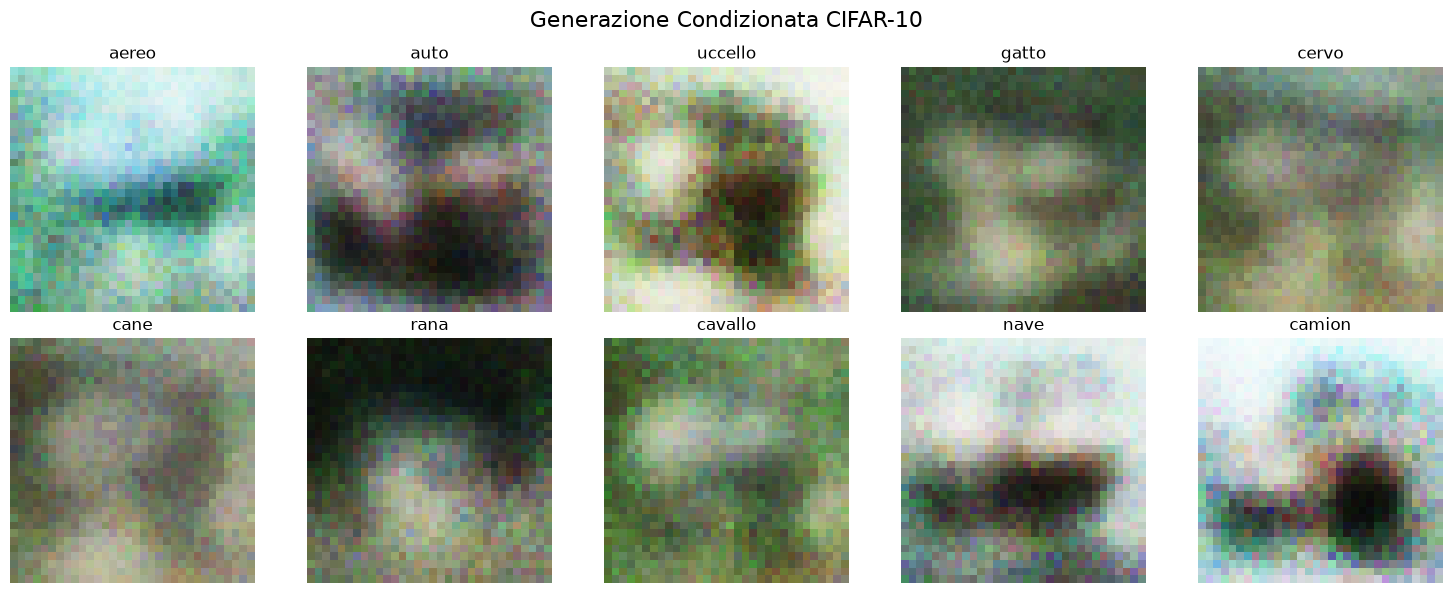

In [8]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from tqdm import tqdm
import matplotlib.pyplot as plt
import numpy as np

import os
import certifi
os.environ["SSL_CERT_FILE"] = certifi.where()

# ==============================================================================
# 1. IMPOSTAZIONI E IPERPARAMETRI
# ==============================================================================
# Selezioniamo il dispositivo di calcolo: GPU NVIDIA (cuda) se disponibile per massimizzare
# la velocità, altrimenti utilizziamo la CPU.
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# --- Configurazione dei Parametri della Rete ---
# Questi valori definiscono le dimensioni e le caratteristiche del modello.
latent_dim = 100        # Dimensione del vettore di 'rumore' casuale in input al generatore.
n_classes = 10          # Numero totale di classi nel dataset CIFAR-10 (aereo, auto, uccello, ecc.).
embed_size = 50         # Dimensione del vettore che rappresenta (embedding) ogni classe.
image_size = 32         # Risoluzione dell'immagine: 32x32 pixel.
channels = 3            # Numero di canali colore: 3 per RGB (Rosso, Verde, Blu).

# Calcoliamo la dimensione totale del vettore immagine appiattito:
# 32 (altezza) * 32 (larghezza) * 3 (colori) = 3072 valori.
flat_dim = image_size * image_size * channels

# ==============================================================================
# 2. IL GENERATORE CONDIZIONALE (Conditional Generator)
# ==============================================================================
# Questa classe definisce la rete neurale responsabile della creazione (generazione) delle immagini.
# È 'condizionale' perché prende come input sia il rumore casuale sia l'etichetta della classe
# che vogliamo generare (es. "generami un'automobile").
class ConditionalGenerator(nn.Module):
    def __init__(self):
        super().__init__()
        
        # --- Strato di Embedding ---
        # Trasforma l'indice della classe (es. un numero da 0 a 9) in un vettore denso di numeri reali.
        # Questo aiuta la rete a comprendere meglio le differenze tra le varie classi.
        self.label_embed = nn.Embedding(n_classes, embed_size)
        
        # --- Architettura della Rete (MLP - Multi-Layer Perceptron) ---
        # Una sequenza di strati lineari (Fully Connected) che trasformano l'input progressivamente.
        self.model = nn.Sequential(
            # Primo livello Linear:
            # L'input è la concatenazione del rumore (latent_dim) e dell'embedding della classe (embed_size).
            nn.Linear(latent_dim + embed_size, 512),
            # ReLU (Rectified Linear Unit): introduce non-linearità, attivando solo i neuroni con valore positivo.
            nn.ReLU(True),
            
            # Secondo livello: espande la rappresentazione da 512 a 1024 neuroni.
            nn.Linear(512, 1024),
            nn.ReLU(True),
            
            # Terzo livello: espande ulteriormente da 1024 a 2048 neuroni.
            nn.Linear(1024, 2048),
            nn.ReLU(True),
            
            # Livello di Output:
            # Riduce la dimensione a 'flat_dim' (3072), che corrisponde ai singoli pixel dell'immagine.
            nn.Linear(2048, flat_dim),
            
            # Tanh (Tangente Iperbolica):
            # Comprime tutti i valori in uscita nell'intervallo [-1, 1].
            # Questo è essenziale perché le immagini reali saranno normalizzate nello stesso intervallo.
            nn.Tanh()
        )

    # Il metodo forward definisce come i dati fluiscono attraverso la rete.
    def forward(self, noise, labels):
        # 1. Otteniamo la rappresentazione vettoriale (embedding) per le classi richieste.
        c = self.label_embed(labels)
        
        # 2. Concateniamo il vettore di rumore con l'embedding della classe.
        # 'dim=1' indica che uniamo i vettori lungo la dimensione delle caratteristiche.
        x = torch.cat([noise, c], dim=1)
        
        # 3. Passiamo i dati uniti attraverso la rete definita in __init__.
        out = self.model(x)
        
        # 4. Rimodelliamo l'output lineare (vettore) in un tensore immagine 3D.
        # -1 lascia a PyTorch il compito di calcolare la dimensione del batch.
        # Risultato: (Batch, 3 Canali, 32 Altezza, 32 Larghezza).
        return out.view(-1, channels, image_size, image_size)

# ==============================================================================
# 3. IL DISCRIMINATORE CONDIZIONALE (Conditional Discriminator)
# ==============================================================================
# Questa classe definisce la rete che deve distinguere tra immagini vere (dal dataset) e false (dal generatore).
# Anche questa è 'condizionale': riceve l'immagine e l'etichetta associata per verificare la coerenza.
class ConditionalDiscriminator(nn.Module):
    def __init__(self):
        super().__init__()
        
        # --- Strato di Embedding ---
        # Stesso concetto del generatore: trasforma l'etichetta di classe in un vettore.
        self.label_embed = nn.Embedding(n_classes, embed_size)
        
        # --- Architettura del Discriminatore ---
        self.model = nn.Sequential(
            # Input:
            # Riceve l'immagine appiattita (flat_dim) + l'embedding della classe (embed_size).
            nn.Linear(flat_dim + embed_size, 1024),
            # LeakyReLU: simile a ReLU, ma permette un piccolo passaggio di segnale anche per valori negativi (0.2).
            # Questo evita che i neuroni 'muoiano' completamente durante l'addestramento.
            nn.LeakyReLU(0.2, inplace=True),
            
            # Riduzione progressiva della dimensionalità.
            nn.Linear(1024, 512),
            nn.LeakyReLU(0.2, inplace=True),
            
            nn.Linear(512, 256),
            nn.LeakyReLU(0.2, inplace=True),
            
            # Output finale: un singolo neurone.
            nn.Linear(256, 1),
            # Sigmoid: schiaccia l'output tra 0 e 1, rappresentando una probabilità.
            # 1.0 = Sicuramente Reale, 0.0 = Sicuramente Falsa.
            nn.Sigmoid()
        )

    def forward(self, img, labels):
        # 1. Appiattiamo l'immagine da 3D (3, 32, 32) a 1D (3072) per poterla passare ai livelli lineari.
        img_flat = img.view(img.size(0), -1)
        
        # 2. Otteniamo l'embedding della classe.
        c = self.label_embed(labels)
        
        # 3. Concateniamo l'immagine appiattita con l'embedding della classe.
        x = torch.cat([img_flat, c], dim=1)
        
        # 4. Calcoliamo la probabilità di autenticità.
        return self.model(x)

# ==============================================================================
# 4. INIZIALIZZAZIONE
# ==============================================================================
# Creiamo le istanze del Generatore e del Discriminatore e le carichiamo sulla memoria del dispositivo (GPU/CPU).
gen = ConditionalGenerator().to(device)
disc = ConditionalDiscriminator().to(device)

# ==============================================================================
# 5. PREPARAZIONE DEL DATASET
# ==============================================================================
# Definiamo le trasformazioni da applicare alle immagini prima dell'uso.
# essendo un dataset molto corposo, e va in errore il codice, scarico il dataset dal questo sito:
# https://www.cs.toronto.edu/~kriz/cifar-10-python.tar.gz e lo salvo 
# in C:\EPICODE\Epicode_Python_AI_MachineLearning\PYTHON\Modulo_6_Generative\2_GANs\data
# il file .py si trova qui: C:\EPICODE\Epicode_Python_AI_MachineLearning\PYTHON\Modulo_6_Generative\2_GANs
# poi cambio dataset = datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
# chiedendo di non fare il download
# dataset = datasets.CIFAR10(root='./data', train=True, download=False, transform=transform)
transform = transforms.Compose([
    transforms.ToTensor(), # Converte l'immagine in un tensore PyTorch.
    # Normalizza i valori dei pixel per ogni canale (R, G, B).
    # Da [0, 1] (default ToTensor) a [-1, 1].
    # (valore - media) / deviazione_standard -> (x - 0.5) / 0.5
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

print("Caricamento dataset CIFAR-10...")
# Scarichiamo e carichiamo il dataset CIFAR-10 di addestramento.
#dataset = datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
dataset = datasets.CIFAR10(root='./data', train=True, download=False, transform=transform)

# Il DataLoader gestisce il caricamento dei dati in 'batch' (gruppi) e rimescola i dati (shuffle) ad ogni epoca.
dataloader = DataLoader(dataset, batch_size=64, shuffle=True)

# ==============================================================================
# 6. OTTIMIZZAZIONE E LOSS
# ==============================================================================
# Usiamo l'ottimizzatore Adam, molto efficace per le GAN.
# lr=0.0002 e betas=(0.5, 0.999) sono valori standard consigliati in letteratura per stabilità.
opt_gen = optim.Adam(gen.parameters(), lr=0.0002, betas=(0.5, 0.999))
opt_disc = optim.Adam(disc.parameters(), lr=0.0002, betas=(0.5, 0.999))

# Binary Cross Entropy Loss: funzione di perdita standard per classificazione binaria (Reale vs Falso).
criterion = nn.BCELoss()

# ==============================================================================
# 7. CICLO DI ADDESTRAMENTO (TRAINING LOOP)
# ==============================================================================

# ==============================================================================
# 7. FUNZIONE DI ADDESTRAMENTO
# ==============================================================================
def train_model(num_epochs=50):
    print(f"Inizio addestramento su {device}...")
    
    for epoch in range(num_epochs):
        # Utilizziamo tqdm per mostrare una barra di progresso durante l'epoca.
        progress_bar = tqdm(enumerate(dataloader), total=len(dataloader), leave=True)
        
        # Iteriamo su ogni batch di immagini reali.
        for i, (real_imgs, labels) in progress_bar:
            # Dimensione attuale del batch (può variare per l'ultimo batch).
            batch_size = real_imgs.size(0)
            
            # Spostiamo i dati sulla GPU/CPU.
            real_imgs, labels = real_imgs.to(device), labels.to(device)

            # -----------------------------------------------------------
            # FASE A: ADDESTRAMENTO DEL DISCRIMINATORE
            # Obiettivo: Massimizzare la capacità di distinguere vero da falso.
            # -----------------------------------------------------------
            # Azzeriamo i gradienti accumulati nel passaggio precedente.
            opt_disc.zero_grad()
            
            # 1. Addestramento su Immagini REALI
            # Chiediamo al discriminatore di valutare le immagini reali.
            validity_real = disc(real_imgs, labels)
            
            # Creiamo un target di soli '1' (che significa 'Reale').
            real_targets = torch.ones(batch_size, 1).to(device)
            
            # Calcoliamo l'errore (Loss) rispetto al target reale.
            loss_real = criterion(validity_real, real_targets)
            
            # 2. Addestramento su Immagini FALSE
            # Generiamo rumore casuale ed etichette casuali.
            noise = torch.randn(batch_size, latent_dim).to(device)
            gen_labels = torch.randint(0, n_classes, (batch_size,)).to(device)
            
            # Il generatore crea immagini false.
            fake_imgs = gen(noise, gen_labels)
            
            # Valutiamo le immagini false.
            # NOTA IMPORTANTE: usiamo .detach() su fake_imgs per rompere il grafo computazionale.
            # Non vogliamo aggiornare il Generatore durante la fase del Discriminatore.
            validity_fake = disc(fake_imgs.detach(), gen_labels)
            
            # Creiamo un target di soli '0' (che significa 'Falso').
            fake_targets = torch.zeros(batch_size, 1).to(device)
            
            # Calcoliamo l'errore sulle immagini false.
            loss_fake = criterion(validity_fake, fake_targets)
            
            # 3. Aggiornamento Pesi Discriminatore
            # La Loss totale è la media tra l'errore sul reale e l'errore sul falso.
            loss_d = (loss_real + loss_fake) / 2
            loss_d.backward() # Calcolo dei gradienti.
            opt_disc.step()   # Aggiornamento parametri.

            # -----------------------------------------------------------
            # FASE B: ADDESTRAMENTO DEL GENERATORE
            # Obiettivo: Ingannare il discriminatore (fargli credere che le false siano vere).
            # -----------------------------------------------------------
            opt_gen.zero_grad()
            
            # 1. Valutazione nuova
            # Valutiamo di nuovo le immagini false (questa volta il grafo è mantenuto per aggiornare il generatore).
            validity = disc(fake_imgs, gen_labels)
            
            # 2. Calcolo Loss Generatore
            # Il generatore vuole che le sue immagini siano classificate come REALI (target 1).
            # Se il discriminatore dice '0', l'errore sarà alto e il generatore imparerà a migliorare.
            loss_g = criterion(validity, real_targets) # Riutilizziamo real_targets (tutti 1).
            
            # 3. Aggiornamento Pesi Generatore
            loss_g.backward()
            opt_gen.step()

            # Aggiorniamo la barra di progresso con le loss correnti.
            progress_bar.set_description(f"Epoch [{epoch+1}/{num_epochs}]")
            progress_bar.set_postfix(D_loss=loss_d.item(), G_loss=loss_g.item())

    print("\nAddestramento completato!")

# ==============================================================================
# 8. VISUALIZZAZIONE DEI RISULTATI
# ==============================================================================
def visualizza_risultati_cifar():
    print("Inizio procedura di visualizzazione risultati...")
    
    # Pulizia della cache GPU per liberare memoria.
    if device.type == 'cuda':
        torch.cuda.empty_cache()
    
    # Mettiamo il generatore in modalità valutazione (utile se ci fossero dropout o batchnorm).
    gen.eval()
    
    # Nomi delle classi CIFAR-10 per visualizzare le etichette corrette.
    classes = ('aereo', 'auto', 'uccello', 'gatto', 'cervo', 'cane', 'rana', 'cavallo', 'nave', 'camion')
    
    print("Generazione delle immagini in corso...")
    # Generiamo 10 immagini, una per ogni classe (da 0 a 9).
    noise = torch.randn(10, latent_dim).to(device)
    labels = torch.arange(10).to(device) # Tensore [0, 1, 2, ..., 9]
    
    # no_grad() disabilita il calcolo dei gradienti, risparmiando memoria e tempo.
    with torch.no_grad():
        fake_imgs = gen(noise, labels).cpu() # Portiamo i risultati su CPU per il plot.
    
    print("Creazione della griglia grafica...")
    # Creiamo una griglia di visualizzazione.
    plt.figure(figsize=(15, 6))
    for i in range(10):
        plt.subplot(2, 5, i+1)
        
        # Denormalizzazione:
        # L'uscita è in [-1, 1]. La riportiamo in [0, 1] per visualizzarla correttamente con matplotlib.
        # Formula inversa: x_denorm = x_norm * 0.5 + 0.5
        img = fake_imgs[i] / 2 + 0.5
        
        # Conversione formato:
        # PyTorch usa (Canali, Altezza, Larghezza).
        # Matplotlib vuole (Altezza, Larghezza, Canali).
        # np.transpose riordina gli assi secondo l'ordine specificato (1, 2, 0).
        img = np.transpose(img.numpy(), (1, 2, 0))
        
        plt.imshow(img)
        plt.title(classes[i])
        plt.axis('off') # Nascondiamo gli assi per pulizia.
    
    plt.suptitle("Generazione Condizionata CIFAR-10", fontsize=16)
    plt.tight_layout()
    
    # Salviamo l'immagine su disco per sicurezza
    print("Salvataggio dell'immagine 'cifar_results.png'...")
    plt.savefig('cifar_results.png')
    print("Immagine salvata correttamente.")
    
    print("Apertura finestra grafica (chiudi la finestra per terminare lo script)...")
    plt.show()

if __name__ == "__main__":
    # Eseguiamo il training solo se lo script è lanciato direttamente
    train_model(num_epochs=10)
    visualizza_risultati_cifar()
